In [ ]:
import sys, os
!{sys.executable} -m pip uninstall -y numpy pandas scikit-learn catboost >/dev/null 2>&1
!{sys.executable} -m pip install -q --upgrade --force-reinstall \
  "numpy==2.1.3" "pandas==2.2.2" "scikit-learn==1.5.2" "catboost==1.2.8"

os.kill(os.getpid(), 9)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.6/111.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import numpy as np, pandas as pd, sklearn, catboost
print("numpy   :", np.__version__)
print("pandas  :", pd.__version__)
print("sklearn :", sklearn.__version__)
print("catboost:", catboost.__version__)


numpy   : 2.1.3
pandas  : 2.2.2
sklearn : 1.5.2
catboost: 1.2.8


/tmp/ipython-input-2692144986.py:31: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return s.dtype == "object" or pd.api.types.is_bool_dtype(s) or pd.api.types.is_categorical_dtype(s)


0:	learn: 1.1637927	test: 1.1804869	best: 1.1804869 (0)	total: 57.4ms	remaining: 1m 8s
200:	learn: 0.2490245	test: 0.2557288	best: 0.2557288 (200)	total: 1.42s	remaining: 7.07s
400:	learn: 0.2198707	test: 0.2325489	best: 0.2325489 (400)	total: 2.84s	remaining: 5.66s
600:	learn: 0.2063402	test: 0.2243343	best: 0.2243343 (600)	total: 5.15s	remaining: 5.14s
800:	learn: 0.1969969	test: 0.2202739	best: 0.2202739 (800)	total: 7.52s	remaining: 3.74s
1000:	learn: 0.1896484	test: 0.2175201	best: 0.2175201 (1000)	total: 10.6s	remaining: 2.1s
1199:	learn: 0.1834623	test: 0.2163041	best: 0.2162851 (1197)	total: 12.2s	remaining: 0us

bestTest = 0.2162850958
bestIteration = 1197

Shrink model to first 1198 iterations.
{'RMSE_log': 0.21628509325245343, 'R2': 0.9687077303552926}

Top-10 SHAP (mean|SHAP|):
       feature  mean_abs_shap
0      Traffic       0.545559
1     Category       0.225506
2          DAU       0.182678
3  Revenue ($)       0.166809
4      RPD ($)       0.100081
5   ARPDAU ($)     

/tmp/ipython-input-2692144986.py:148: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Blues")


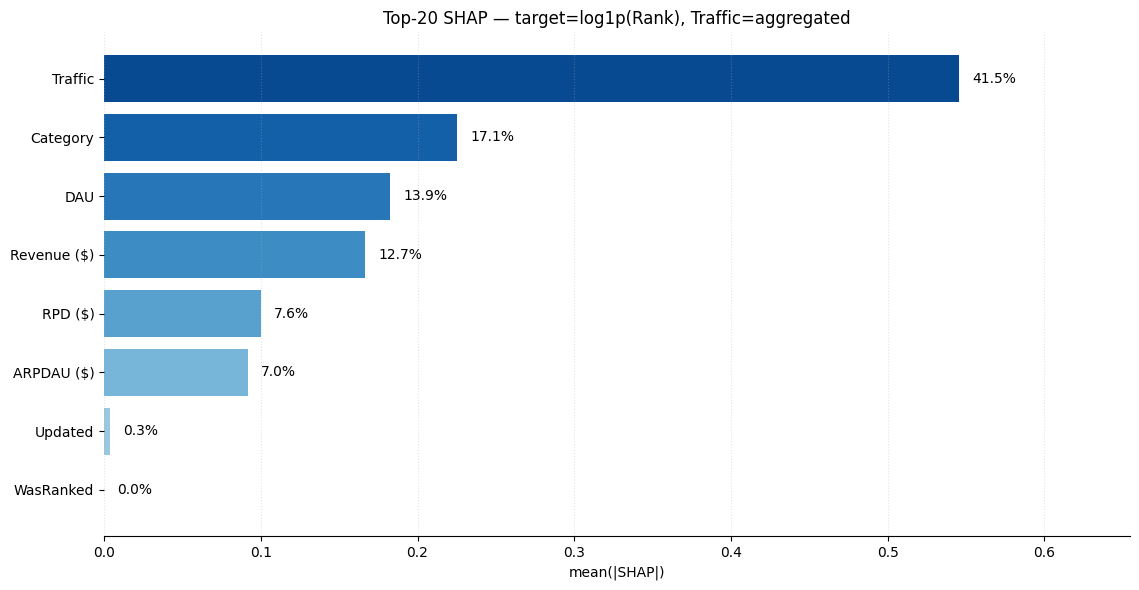

Saved: /content/rank_drivers_out/{shap_global.csv, top20_shap.csv, top20_shap_blue.png, metrics.txt}


In [ ]:
# Target = log1p(Rank)

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from typing import List
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor, Pool

RANDOM_STATE = 42
CSV_PATH = "/content/GooglePlay_AllMerged_FINAL_2021_augmented.csv"
TARGET_COL = "Rank"
DROP_COLS = {"App ID", "Date"}

CHANNEL_COLS = [
    "Organic Search", "Organic Browse",
    "Paid Ads", "Paid Search",
    "Web Browser"
]
AGG_COLS = ["Organic Traffic", "Paid Traffic"]

def is_num(s: pd.Series) -> bool:
    return pd.api.types.is_numeric_dtype(s)

def is_cat_like(s: pd.Series) -> bool:
    return s.dtype == "object" or pd.api.types.is_bool_dtype(s) or pd.api.types.is_categorical_dtype(s)

def safe_clip_rank(df: pd.DataFrame, target: str) -> pd.DataFrame:
    d = df.copy()
    d[target] = d[target].clip(1.0, 5000.0)
    return d

# Load
df_raw = pd.read_csv(CSV_PATH)
if TARGET_COL not in df_raw.columns:
    raise ValueError(f"Не найдена колонка таргета '{TARGET_COL}'.")

df = df_raw.copy()
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=[TARGET_COL])
df = safe_clip_rank(df, TARGET_COL)

# Build Traffic (aggregated)
avail_channels = [c for c in CHANNEL_COLS if c in df.columns]
avail_aggs = [c for c in AGG_COLS if c in df.columns]

if len(avail_channels) >= 1:
    df["Traffic"] = df[avail_channels].fillna(0).sum(axis=1)
elif len(avail_aggs) >= 1:
    df["Traffic"] = df[avail_aggs].fillna(0).sum(axis=1)
else:
    raise ValueError("Не нашёл колонок трафика — добавь хотя бы канал или агрегат.")

# Feature set
candidates = [c for c in df.columns if c not in DROP_COLS and c != TARGET_COL]

traffic_drop = set(avail_channels + avail_aggs)
feature_cols = [c for c in candidates if c not in traffic_drop]

if "Traffic" not in feature_cols:
    feature_cols.append("Traffic")

# типы
num_cols = [c for c in feature_cols if is_num(df[c])]
cat_cols = [c for c in feature_cols if is_cat_like(df[c])]

# log1p для числовых НЕ-бинарных и неотрицательных
log_cols: List[str] = []
for c in num_cols:
    s = pd.to_numeric(df[c], errors="coerce")
    if s.nunique(dropna=True) <= 2:   # бинарные не логируем
        continue
    if s.dropna().min() < 0:
        continue
    log_cols.append(c)
# применяем лог-трансформацию (включая Traffic, если она не бинарная)
for c in log_cols:
    df[c] = np.log1p(np.maximum(df[c].astype(float), 0.0))

for c in cat_cols:
    df[c] = df[c].astype(str)

y = np.log1p(df[TARGET_COL].astype(float).to_numpy())
X = df[feature_cols].copy()

# Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

cat_idx = [X.columns.get_loc(c) for c in cat_cols if c in X.columns]
train_pool = Pool(X_train, y_train, cat_features=cat_idx, feature_names=list(X.columns))
test_pool  = Pool(X_test,  y_test,  cat_features=cat_idx, feature_names=list(X.columns))

# Model
cb = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.045,
    depth=6,
    random_seed=RANDOM_STATE,
    loss_function="RMSE",
    eval_metric="RMSE",
    od_type="Iter",
    od_wait=80,
    verbose=200
)
cb.fit(train_pool, eval_set=test_pool, use_best_model=True)

y_pred = cb.predict(test_pool)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2   = float(r2_score(y_test, y_pred))
print({"RMSE_log": rmse, "R2": r2})

# SHAP (TreeSHAP via CatBoost)
rng = np.random.RandomState(RANDOM_STATE)
n_sample = min(20000, len(X_train))
idx = rng.choice(len(X_train), size=n_sample, replace=False)
pool_shap = Pool(X_train.iloc[idx], y_train[idx], cat_features=cat_idx, feature_names=list(X.columns))

# shap_vals shape: [n_sample, n_features + 1] (последняя колонка — base value)
shap_vals = cb.get_feature_importance(pool_shap, type="ShapValues")
shap_global = np.abs(shap_vals[:, :-1]).mean(axis=0)

shap_df = (pd.DataFrame({"feature": X.columns, "mean_abs_shap": shap_global})
           .sort_values("mean_abs_shap", ascending=False)
           .reset_index(drop=True))

print("\nTop-10 SHAP (mean|SHAP|):")
print(shap_df.head(10))

# Plot: Top SHAP
os.makedirs("/content/rank_drivers_out", exist_ok=True)

top20 = shap_df.head(20).copy()
top20["share_%"] = top20["mean_abs_shap"] / top20["mean_abs_shap"].sum() * 100

n = len(top20)
cmap = plt.cm.get_cmap("Blues")
colors = [cmap(v) for v in np.linspace(0.9, 0.3, n)]

fig, ax = plt.subplots(figsize=(11.5, 6))
ypos = np.arange(n)
ax.barh(ypos, top20["mean_abs_shap"].values, color=colors)
ax.set_yticks(ypos)
ax.set_yticklabels(top20["feature"].values)
ax.invert_yaxis()
ax.set_xlabel("mean(|SHAP|)")
ax.set_title("Top-20 SHAP — target=log1p(Rank), Traffic=aggregated")

max_val = float(top20["mean_abs_shap"].max())
ax.set_xlim(0, max_val * 1.2)
for i, (v, pct) in enumerate(zip(top20["mean_abs_shap"].values, top20["share_%"].values)):
    ax.text(v + max_val * 0.015, i, f"{pct:.1f}%", va="center", ha="left", fontsize=10)

ax.grid(axis="x", linestyle=":", alpha=0.35)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)

plt.tight_layout()
plt.savefig("/content/rank_drivers_out/top20_shap_blue.png", dpi=200, bbox_inches="tight")
plt.show()

# Save
shap_df.to_csv("/content/rank_drivers_out/shap_global.csv", index=False)
top20.to_csv("/content/rank_drivers_out/top20_shap.csv", index=False)
with open("/content/rank_drivers_out/metrics.txt", "w", encoding="utf-8") as f:
    f.write(f"RMSE_log: {rmse:.6f}\nR2: {r2:.6f}\n")
    f.write("Target = log1p(Rank)\n")
    f.write("Traffic aggregated from channels or aggregates (no double-counting)\n")

print("Saved: /content/rank_drivers_out/{shap_global.csv, top20_shap.csv, top20_shap_blue.png, metrics.txt}")


/tmp/ipython-input-63748726.py:21: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return s.dtype == "object" or pd.api.types.is_bool_dtype(s) or pd.api.types.is_categorical_dtype(s)


0:	learn: 2.7316820	test: 2.7336935	best: 2.7336935 (0)	total: 2.18s	remaining: 43m 31s
200:	learn: 0.5853934	test: 0.5825274	best: 0.5825274 (200)	total: 4m 24s	remaining: 21m 52s
400:	learn: 0.5286636	test: 0.5271379	best: 0.5271379 (400)	total: 8m 52s	remaining: 17m 41s
600:	learn: 0.4918396	test: 0.4907598	best: 0.4907598 (600)	total: 13m 27s	remaining: 13m 24s
800:	learn: 0.4655365	test: 0.4644795	best: 0.4644795 (800)	total: 17m 55s	remaining: 8m 55s
1000:	learn: 0.4467947	test: 0.4458145	best: 0.4458145 (1000)	total: 22m 24s	remaining: 4m 27s
1199:	learn: 0.4321427	test: 0.4312800	best: 0.4312800 (1199)	total: 26m 50s	remaining: 0us

bestTest = 0.4312799872
bestIteration = 1199

{'RMSE_log': 0.43127998801632395, 'R2': 0.9771316672056718}

Top-10 SHAP (mean|SHAP|):
        feature  mean_abs_shap
0  OtherTraffic       2.013984
1       RPD ($)       0.563615
2           DAU       0.507583
3   Revenue ($)       0.505761
4    ARPDAU ($)       0.211820
5      Category       0.125658
6

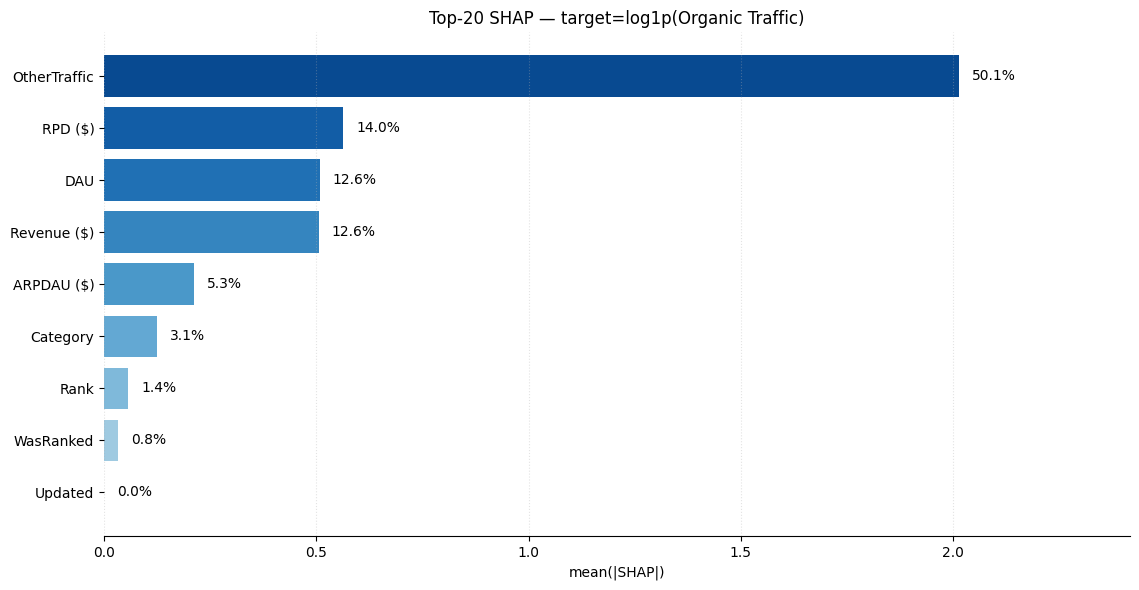


Top-10 consensus:
        feature  consensus  shap_norm  perm_norm
0  OtherTraffic   1.000000   1.000000   1.000000
1       RPD ($)   0.492714   0.279851   0.705577
2   Revenue ($)   0.294855   0.251124   0.338585
3           DAU   0.165782   0.252030   0.079535
4    ARPDAU ($)   0.124499   0.105175   0.143823
5      Category   0.048005   0.062393   0.033617
6          Rank   0.021826   0.028528   0.015124
7     WasRanked   0.012580   0.016442   0.008718
8       Updated   0.000000   0.000000   0.000000


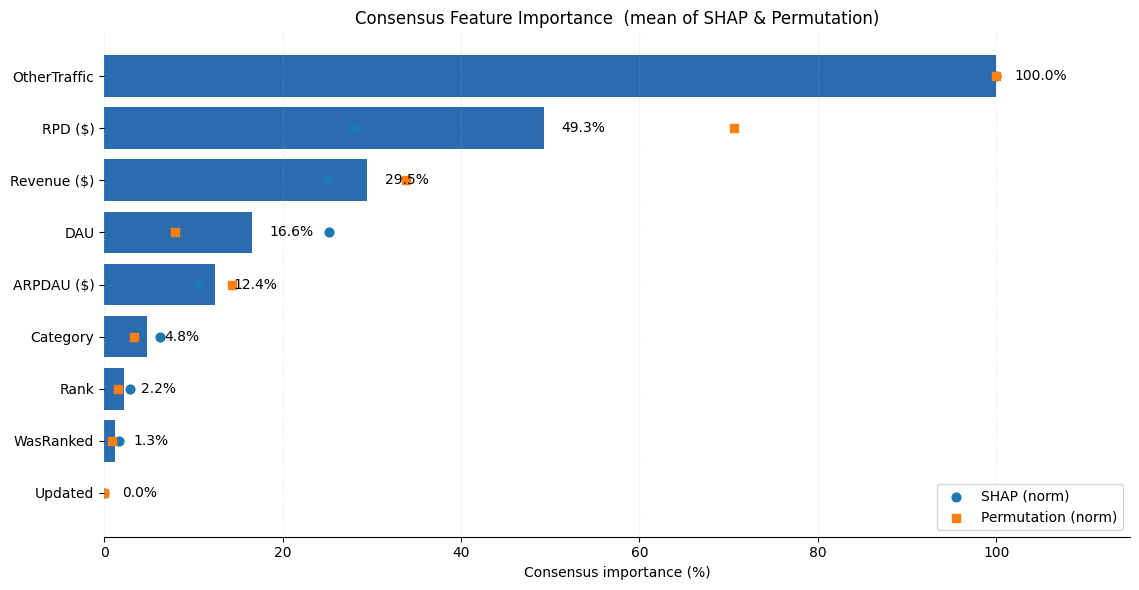

Saved: metrics_organic.txt, top20_shap_organic.png, consensus_importance_organic.png, and CSVs in /content/rank_drivers_out


In [ ]:
# Target = Organic Traffic (Organic Search + Organic Browse)

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from typing import List
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor, Pool

RANDOM_STATE = 42
CSV_PATH = "/content/GooglePlay_AllMerged_FINAL_2021_augmented.csv"

# helpers
def is_num(s: pd.Series) -> bool:
    return pd.api.types.is_numeric_dtype(s)

def is_cat_like(s: pd.Series) -> bool:
    return s.dtype == "object" or pd.api.types.is_bool_dtype(s) or pd.api.types.is_categorical_dtype(s)

def safe_clip(x: pd.Series, lo=0.0):
    return np.maximum(pd.to_numeric(x, errors="coerce"), lo)

def describe(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2   = float(r2_score(y_true, y_pred))
    return {"RMSE_log": rmse, "R2": r2}

# load
df = pd.read_csv(CSV_PATH).replace([np.inf, -np.inf], np.nan)

# build Organic Traffic (target)
if {"Organic Search","Organic Browse"}.issubset(df.columns):
    df["Organic Traffic"] = df["Organic Search"].fillna(0) + df["Organic Browse"].fillna(0)
elif "Organic Traffic" in df.columns:
    df["Organic Traffic"] = df["Organic Traffic"].fillna(0)
else:
    raise ValueError("Нет столбцов для Organic Traffic: нужны Organic Search+Organic Browse или готовый Organic Traffic.")

TARGET_COL = "Organic Traffic"

# build OtherTraffic (independent aggregated)
channels_other = [c for c in ["Paid Ads","Paid Search","Web Browser"] if c in df.columns]
if len(channels_other) > 0:
    df["OtherTraffic"] = df[channels_other].fillna(0).sum(axis=1)
elif "Paid Traffic" in df.columns:
    df["OtherTraffic"] = df["Paid Traffic"].fillna(0)
else:
    raise ValueError("Нет столбцов для OtherTraffic: нужны Paid Ads/Paid Search/Web Browser или Paid Traffic.")

# drop unusable targets and columns
DROP_COLS = {"App ID","Date"}
df = df.dropna(subset=[TARGET_COL])

# feature set
exclude_raw = {TARGET_COL} | DROP_COLS | {"Organic Search","Organic Browse","Paid Traffic"} | set(channels_other)
feature_cols = [c for c in df.columns if c not in exclude_raw and c != TARGET_COL]

# типы
num_cols = [c for c in feature_cols if is_num(df[c])]
cat_cols = [c for c in feature_cols if is_cat_like(df[c])]

# логарифмируем числовые небинарные и неотрицательные
log_cols: List[str] = []
for c in num_cols + ["OtherTraffic"]:
    s = safe_clip(df[c], lo=0.0)
    if s.nunique(dropna=True) > 2:  # не бинарная
        log_cols.append(c)
for c in log_cols:
    df[c] = np.log1p(safe_clip(df[c], lo=0.0))

for c in cat_cols:
    df[c] = df[c].astype(str)

y = np.log1p(safe_clip(df[TARGET_COL], lo=0.0).values.astype(float))
X = df[feature_cols + (["OtherTraffic"] if "OtherTraffic" not in feature_cols else [])].copy()

# индексы категориальных
cat_idx = [X.columns.get_loc(c) for c in cat_cols if c in X.columns]

# split & pools
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
train_pool = Pool(X_train, y_train, cat_features=cat_idx, feature_names=list(X.columns))
test_pool  = Pool(X_test,  y_test,  cat_features=cat_idx, feature_names=list(X.columns))

#  model
cb = CatBoostRegressor(
    iterations=1200, learning_rate=0.045, depth=6,
    random_seed=RANDOM_STATE, loss_function="RMSE", eval_metric="RMSE",
    od_type="Iter", od_wait=80, verbose=200
)
cb.fit(train_pool, eval_set=test_pool, use_best_model=True)

pred = cb.predict(test_pool)
metrics = describe(y_test, pred)
print(metrics)

# SHAP (TreeSHAP)
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X_train), size=min(40000, len(X_train)), replace=False)
pool_shap = Pool(X_train.iloc[idx], y_train[idx], cat_features=cat_idx, feature_names=list(X.columns))

shap_vals = cb.get_feature_importance(pool_shap, type="ShapValues")  # [n, n_features+1]
shap_global = np.abs(shap_vals[:, :-1]).mean(axis=0)
shap_df = (pd.DataFrame({"feature": X.columns, "mean_abs_shap": shap_global})
           .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))

print("\nTop-10 SHAP (mean|SHAP|):")
print(shap_df.head(10))

# SHAP bar chart
os.makedirs("/content/rank_drivers_out", exist_ok=True)
top20 = shap_df.head(20).copy()
top20["share_%"] = top20["mean_abs_shap"] / max(top20["mean_abs_shap"].sum(), 1e-9) * 100

plt.figure(figsize=(11.5, 6))
ypos = np.arange(len(top20))
colors = [plt.cm.Blues(v) for v in np.linspace(0.9, 0.3, len(top20))]
plt.barh(ypos, top20["mean_abs_shap"].values, color=colors)
plt.yticks(ypos, top20["feature"].values)
plt.gca().invert_yaxis()
plt.xlabel("mean(|SHAP|)")
plt.title("Top-20 SHAP — target=log1p(Organic Traffic)")
mx = float(top20["mean_abs_shap"].max())
plt.xlim(0, mx*1.2)
for i,(v,pct) in enumerate(zip(top20["mean_abs_shap"].values, top20["share_%"].values)):
    plt.text(v + mx*0.015, i, f"{pct:.1f}%", va="center", ha="left", fontsize=10)
plt.grid(axis="x", linestyle=":", alpha=0.35)
for s in ("top","right","left"): plt.gca().spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("/content/rank_drivers_out/top20_shap_organic.png", dpi=200, bbox_inches="tight")
plt.show()

# Permutation importance (holdout)
from sklearn.metrics import mean_squared_error

def perm_drop_rmse(model, X_te, y_te, n_repeats=5, seed=42):
    rng = np.random.RandomState(seed)
    base = float(np.sqrt(mean_squared_error(y_te, model.predict(Pool(X_te, cat_features=cat_idx)))))
    out = []
    for c in X_te.columns:
        inc = []
        for _ in range(n_repeats):
            Xp = X_te.copy()
            Xp[c] = rng.permutation(Xp[c].values)
            inc.append(float(np.sqrt(mean_squared_error(y_te, model.predict(Pool(Xp, cat_features=cat_idx)))) - base))
        out.append((c, float(np.mean(inc))))
    return pd.DataFrame(out, columns=["feature","perm_rmse_increase"]).sort_values("perm_rmse_increase", ascending=False)

perm_df = perm_drop_rmse(cb, X_test, y_test, n_repeats=3)

# Consensus (SHAP + Permutation)
m1 = shap_df.copy(); m1["shap_norm"] = m1["mean_abs_shap"] / (m1["mean_abs_shap"].max() or 1)
m2 = perm_df.copy(); m2["perm_norm"] = m2["perm_rmse_increase"] / (m2["perm_rmse_increase"].max() or 1)
cons = (m1[["feature","shap_norm"]].merge(m2[["feature","perm_norm"]], on="feature", how="outer").fillna(0.0))
cons["consensus"] = 0.5*(cons["shap_norm"] + cons["perm_norm"])
cons = cons.sort_values("consensus", ascending=False).reset_index(drop=True)

print("\nTop-10 consensus:")
print(cons.head(10)[["feature","consensus","shap_norm","perm_norm"]])

# Consensus chart
C = cons.head(12).copy()
y = np.arange(len(C))
plt.figure(figsize=(11.5,6))
plt.barh(y, C["consensus"]*100, color="#2b6cb0")
plt.yticks(y, C["feature"])
plt.gca().invert_yaxis()
plt.xlabel("Consensus importance (%)")
plt.title("Consensus Feature Importance  (mean of SHAP & Permutation)")
plt.scatter(C["shap_norm"]*100, y, marker="o", s=40, label="SHAP (norm)")
plt.scatter(C["perm_norm"]*100, y, marker="s", s=40, label="Permutation (norm)")
mx = float(C[["consensus","shap_norm","perm_norm"]].max().max()*100)
plt.xlim(0, mx*1.15)
for i,v in enumerate(C["consensus"]*100):
    plt.text(v + mx*0.02, i, f"{v:.1f}%", va="center", ha="left", fontsize=10)
plt.grid(axis="x", linestyle=":", alpha=0.35)
for s in ("top","right","left"): plt.gca().spines[s].set_visible(False)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/content/rank_drivers_out/consensus_importance_organic.png", dpi=200, bbox_inches="tight")
plt.show()

# Save tables
os.makedirs("/content/rank_drivers_out", exist_ok=True)
shap_df.to_csv("/content/rank_drivers_out/shap_global_organic.csv", index=False)
perm_df.to_csv("/content/rank_drivers_out/perm_importance_organic.csv", index=False)
cons.to_csv("/content/rank_drivers_out/consensus_importance_organic.csv", index=False)

with open("/content/rank_drivers_out/metrics_organic.txt","w",encoding="utf-8") as f:
    f.write(f"{metrics}\n")
    f.write("Target = log1p(Organic Traffic) = log1p(Organic Search + Organic Browse)\n")
    f.write("OtherTraffic aggregated from Paid Ads, Paid Search, Web Browser (or Paid Traffic fallback)\n")

print("Saved: metrics_organic.txt, top20_shap_organic.png, consensus_importance_organic.png, and CSVs in /content/rank_drivers_out")


0:	learn: 1.1369761	test: 1.1373820	best: 1.1373820 (0)	total: 354ms	remaining: 5m 17s
200:	learn: 0.4354958	test: 0.4351842	best: 0.4351842 (200)	total: 46.4s	remaining: 2m 41s
400:	learn: 0.4183003	test: 0.4192918	best: 0.4192918 (400)	total: 1m 30s	remaining: 1m 52s
600:	learn: 0.4105145	test: 0.4125747	best: 0.4125747 (600)	total: 2m 12s	remaining: 1m 5s
800:	learn: 0.4040336	test: 0.4071076	best: 0.4071076 (800)	total: 2m 55s	remaining: 21.6s
899:	learn: 0.4014352	test: 0.4050136	best: 0.4050136 (899)	total: 3m 16s	remaining: 0us

bestTest = 0.4050135837
bestIteration = 899

{'target': 'Rank (log1p)', 'RMSE': 0.4050135835402954, 'R2': 0.8811838461643849}

Rank (log1p) — вклад лагов Updated (mean|SHAP|, % от суммы Upd-лагов):
      feature    share_%  share_pos  mean_pos_shap  mean_neg_shap
8    Upd_lag1  27.082527   0.045875       0.000463      -0.000656
10   Upd_lag3  15.867760   0.053400       0.000210      -0.000445
11   Upd_lag7   2.439544   0.251100       0.000048      -0.000

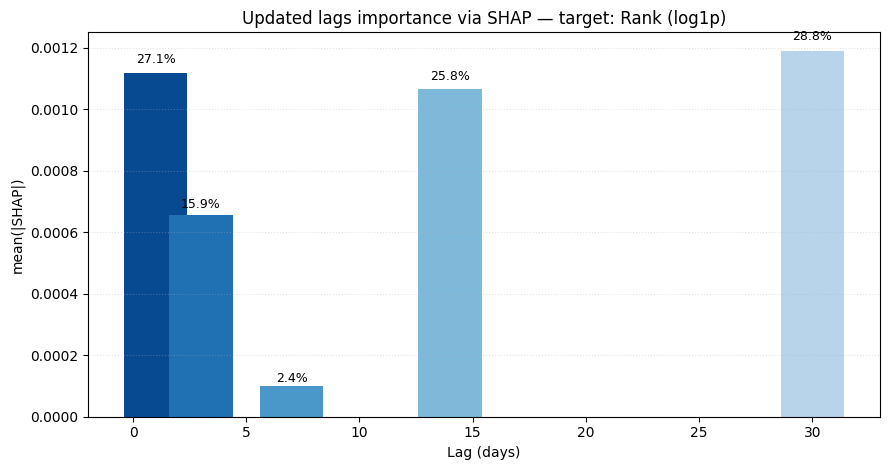

Saved: /content/rank_drivers_out/shap_upd_lags_Rank_(log1p).png
0:	learn: 2.6676920	test: 2.6671516	best: 2.6671516 (0)	total: 1.32s	remaining: 19m 49s
200:	learn: 0.8150311	test: 0.8249988	best: 0.8249988 (200)	total: 3m 40s	remaining: 12m 46s
400:	learn: 0.7922669	test: 0.8029155	best: 0.8029155 (400)	total: 7m 17s	remaining: 9m 4s
600:	learn: 0.7820522	test: 0.7930596	best: 0.7930596 (600)	total: 10m 41s	remaining: 5m 19s
800:	learn: 0.7750315	test: 0.7863245	best: 0.7863245 (800)	total: 14m 11s	remaining: 1m 45s
899:	learn: 0.7713900	test: 0.7829487	best: 0.7829487 (899)	total: 15m 54s	remaining: 0us

bestTest = 0.7829486726
bestIteration = 899

{'target': 'Organic Traffic (log)', 'RMSE': 0.7829486721854151, 'R2': 0.921142937430418}

Organic Traffic (log) — вклад лагов Updated (mean|SHAP|, % от суммы Upd-лагов):
      feature    share_%  share_pos  mean_pos_shap  mean_neg_shap
8    Upd_lag1  21.025197   0.218750       0.000434      -0.000535
11   Upd_lag3  10.474359   0.791450     

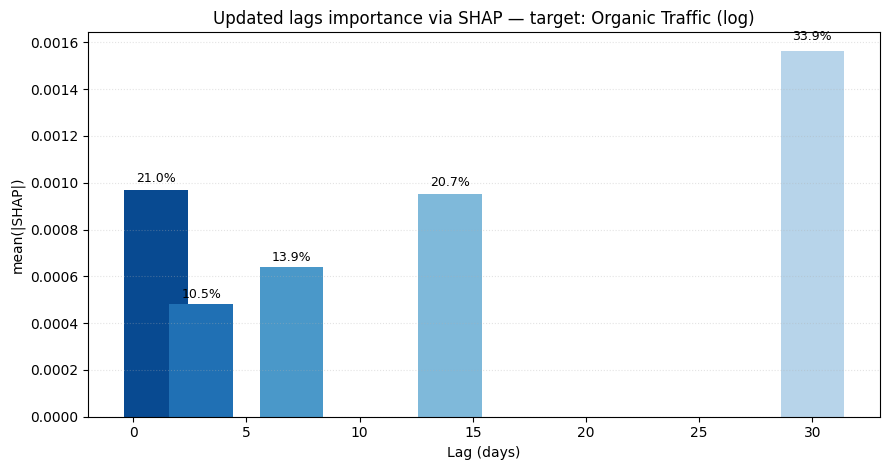

Saved: /content/rank_drivers_out/shap_upd_lags_Organic_Traffic_(log).png
0:	learn: 4.0829977	test: 4.0833751	best: 4.0833751 (0)	total: 2.03s	remaining: 30m 21s
200:	learn: 0.1575164	test: 0.1620835	best: 0.1620835 (200)	total: 3m 50s	remaining: 13m 23s
400:	learn: 0.1536494	test: 0.1584839	best: 0.1584839 (400)	total: 7m 46s	remaining: 9m 40s
600:	learn: 0.1520286	test: 0.1571811	best: 0.1571811 (600)	total: 11m 24s	remaining: 5m 40s
800:	learn: 0.1511991	test: 0.1566030	best: 0.1566030 (800)	total: 14m 56s	remaining: 1m 50s
899:	learn: 0.1509241	test: 0.1564242	best: 0.1564233 (897)	total: 16m 33s	remaining: 0us

bestTest = 0.1564232821
bestIteration = 897

Shrink model to first 898 iterations.
{'target': 'DAU (log)', 'RMSE': 0.15642328253920354, 'R2': 0.9986735306973887}

DAU (log) — вклад лагов Updated (mean|SHAP|, % от суммы Upd-лагов):
      feature    share_%  share_pos  mean_pos_shap  mean_neg_shap
8    Upd_lag1  36.427273   0.038925       0.000750      -0.000598
9    Upd_lag3 

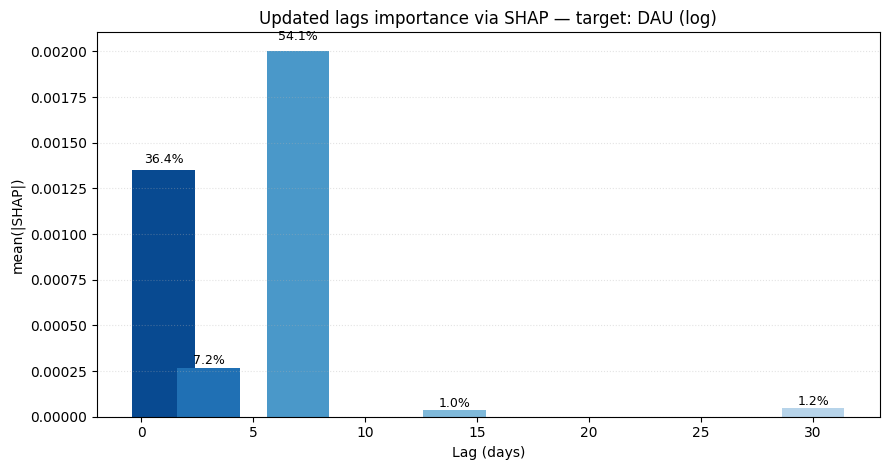

Saved: /content/rank_drivers_out/shap_upd_lags_DAU_(log).png
0:	learn: 3.6168745	test: 3.6196072	best: 3.6196072 (0)	total: 2.59s	remaining: 38m 50s
200:	learn: 2.1675608	test: 2.1711552	best: 2.1711552 (200)	total: 3m 46s	remaining: 13m 6s
400:	learn: 2.1058218	test: 2.1117341	best: 2.1117341 (400)	total: 7m 16s	remaining: 9m 2s
600:	learn: 2.0711657	test: 2.0792677	best: 2.0792677 (600)	total: 10m 44s	remaining: 5m 20s
800:	learn: 2.0503764	test: 2.0600517	best: 2.0600517 (800)	total: 14m 7s	remaining: 1m 44s
899:	learn: 2.0427016	test: 2.0529838	best: 2.0529838 (899)	total: 15m 46s	remaining: 0us

bestTest = 2.052983832
bestIteration = 899

{'target': 'Revenue ($) (log)', 'RMSE': 2.0529838328181618, 'R2': 0.6943175549444098}

Revenue ($) (log) — вклад лагов Updated (mean|SHAP|, % от суммы Upd-лагов):
      feature    share_%  share_pos  mean_pos_shap  mean_neg_shap
7    Upd_lag1  18.206776   0.046350       0.008558      -0.010763
10   Upd_lag3  16.218686   0.067675       0.007528   

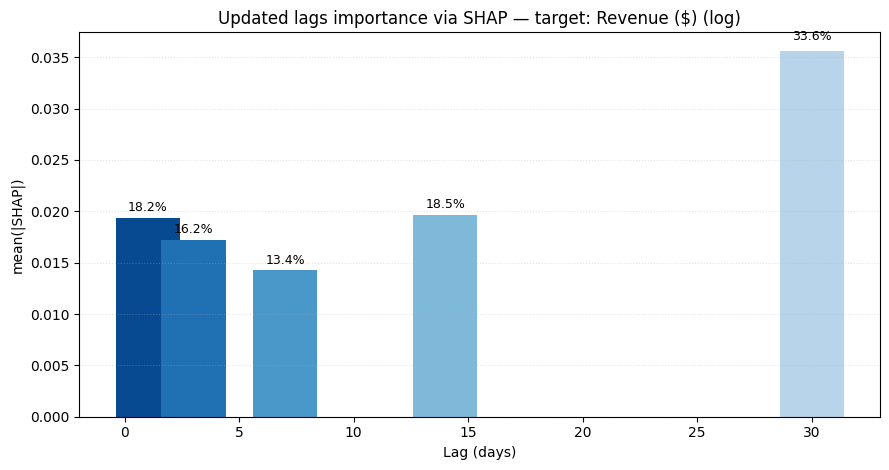

Saved: /content/rank_drivers_out/shap_upd_lags_Revenue_($)_(log).png
0:	learn: 1.2240645	test: 1.2232392	best: 1.2232392 (0)	total: 1.16s	remaining: 17m 21s
200:	learn: 0.8316082	test: 0.8318904	best: 0.8318904 (200)	total: 3m 33s	remaining: 12m 23s
400:	learn: 0.8003938	test: 0.8013258	best: 0.8013258 (400)	total: 6m 59s	remaining: 8m 41s
600:	learn: 0.7842432	test: 0.7856943	best: 0.7856943 (600)	total: 10m 19s	remaining: 5m 8s
800:	learn: 0.7731557	test: 0.7751738	best: 0.7751738 (800)	total: 13m 37s	remaining: 1m 41s
899:	learn: 0.7689769	test: 0.7712711	best: 0.7712711 (899)	total: 15m 15s	remaining: 0us

bestTest = 0.7712710509
bestIteration = 899

{'target': 'RPD ($) (log)', 'RMSE': 0.7712710513237454, 'R2': 0.6124497593942614}

RPD ($) (log) — вклад лагов Updated (mean|SHAP|, % от суммы Upd-лагов):
      feature    share_%  share_pos  mean_pos_shap  mean_neg_shap
8    Upd_lag1  17.506717   0.045950       0.002184      -0.003238
9    Upd_lag3  15.174121   0.049375       0.001978

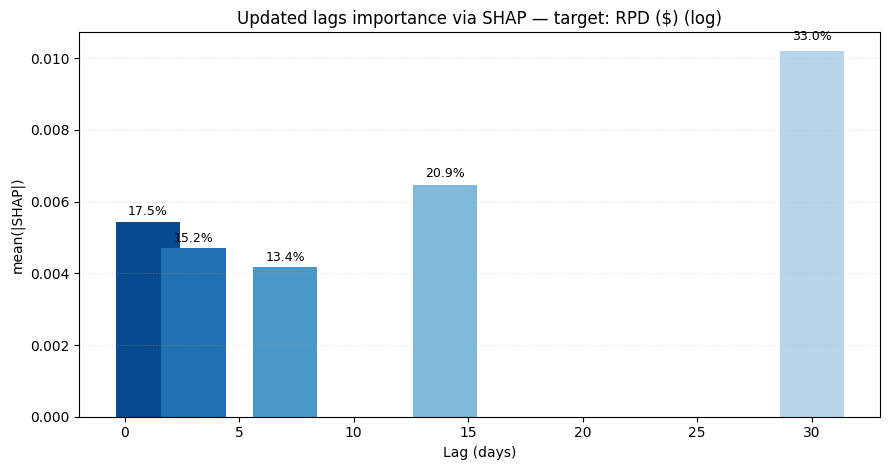

Saved: /content/rank_drivers_out/shap_upd_lags_RPD_($)_(log).png
0:	learn: 0.5003659	test: 0.4995594	best: 0.4995594 (0)	total: 1.15s	remaining: 17m 15s
200:	learn: 0.3821881	test: 0.3821720	best: 0.3821720 (200)	total: 3m 33s	remaining: 12m 22s
400:	learn: 0.3691669	test: 0.3697496	best: 0.3697496 (400)	total: 7m 6s	remaining: 8m 50s
600:	learn: 0.3613599	test: 0.3624790	best: 0.3624790 (600)	total: 10m 54s	remaining: 5m 25s
800:	learn: 0.3557909	test: 0.3573932	best: 0.3573932 (800)	total: 14m 24s	remaining: 1m 46s
899:	learn: 0.3538934	test: 0.3556251	best: 0.3556251 (899)	total: 16m 2s	remaining: 0us

bestTest = 0.35562513
bestIteration = 899

{'target': 'ARPDAU ($) (log)', 'RMSE': 0.35562513011073627, 'R2': 0.5026780859715891}

ARPDAU ($) (log) — вклад лагов Updated (mean|SHAP|, % от суммы Upd-лагов):
      feature    share_%  share_pos  mean_pos_shap  mean_neg_shap
10   Upd_lag1  14.832528   0.075450       0.000644      -0.000902
9    Upd_lag3  15.345776   0.043850       0.000672

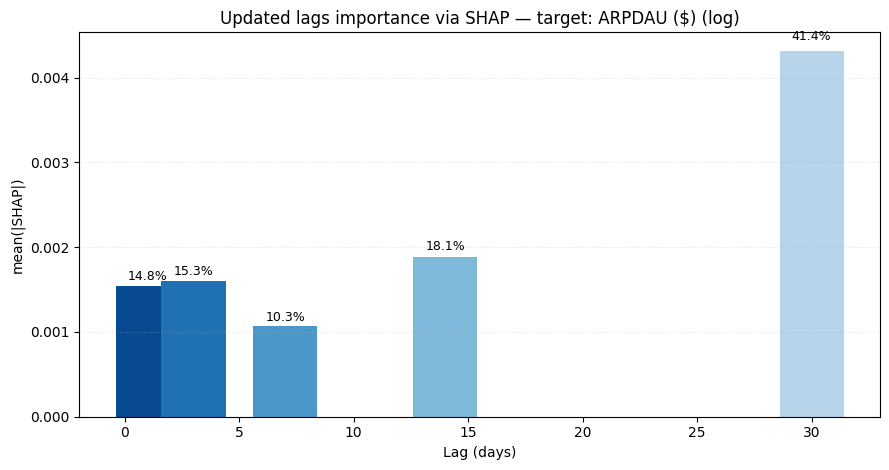

Saved: /content/rank_drivers_out/shap_upd_lags_ARPDAU_($)_(log).png
Saved table: /content/rank_drivers_out/updated_lags_shap_summary.csv


In [ ]:
# CatBoost: эффект апдейтов на метрики
# - Отдельные модели для каждого таргета
# - Фичи: Upd_lag{1,3,7,14,30} + контролы Paid_log_lag{1,7}, DAU_log_lag{1,7}, DOW, Month
# - Таргеты: Organic Traffic, Rank, DAU, Revenue($), RPD($), ARPDAU($)
# - Выход: SHAP важности по лагам Updated для КАЖДОГО таргета + метрики качества

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor, Pool

#  CONFIG
CSV_PATH = "/content/GooglePlay_AllMerged_FINAL_2021_augmented.csv"
RANDOM_STATE = 42
UPD_LAGS = [1, 3, 7, 14, 30]
PAID_LAGS = [1, 7]
DAU_LAGS  = [1, 7]
OUTCOME_CANDIDATES = {
    "Organic Traffic": ["Organic Traffic","organic_traffic","OrganicTraffic"],
    "Rank":            ["Rank","rank"],
    "DAU":             ["DAU","dau"],
    "Revenue ($)":     ["Revenue ($)","Revenue","revenue"],
    "RPD ($)":         ["RPD ($)","RPD","rpd"],
    "ARPDAU ($)":      ["ARPDAU ($)","ARPDAU","arpdau"],
}
EXCLUDE_COLS = {"App ID","Date"}

#  helpers
def find_col(df, options):
    for c in options:
        if c in df.columns: return c
    return None

def log1p_safe(x):
    v = pd.to_numeric(x, errors="coerce")
    v = np.maximum(v, 0.0)
    return np.log1p(v)

def ensure_organic(df):
    if "Organic Traffic" in df.columns:
        return df
    need = {"Organic Search","Organic Browse"}
    if need.issubset(df.columns):
        df["Organic Traffic"] = df["Organic Search"].fillna(0) + df["Organic Browse"].fillna(0)
        return df
    raise ValueError("Нет Organic Traffic и нет (Organic Search + Organic Browse).")

#  load & basic prep
df = pd.read_csv(CSV_PATH).replace([np.inf, -np.inf], np.nan)
df = ensure_organic(df)

# Update flag (унификация разных написаний)
upd_raw = df.get("Updated", df.get("updated", None))
if upd_raw is None:
    raise ValueError("Не найдена колонка Updated/updated.")
df["Updated_flag"] = upd_raw.astype(str).str.strip().str.lower().isin(
    ["update","updated","1","true","yes","y"]
).astype(int)

# Paid total
if "Paid Traffic" in df.columns:
    df["Paid_total"] = pd.to_numeric(df["Paid Traffic"], errors="coerce").fillna(0)
else:
    parts = [c for c in ["Paid Ads","Paid Search","Web Browser"] if c in df.columns]
    if parts:
        df["Paid_total"] = df[parts].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)
    else:
        df["Paid_total"] = 0.0

# DAU numeric
if "DAU" in df.columns:
    df["DAU"] = pd.to_numeric(df["DAU"], errors="coerce")

# Calendar features
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["dow"] = df["Date"].dt.dayofweek.astype("int16")   # 0..6
    df["month"] = df["Date"].dt.month.astype("int16")     # 1..12
else:
    df["dow"] = 0
    df["month"] = 1

# Logs for controls
df["Paid_log"] = log1p_safe(df["Paid_total"])
if "DAU" in df.columns:
    df["DAU_log"] = log1p_safe(df["DAU"])

# Lags: Updated + controls
key_id = "App ID" if "App ID" in df.columns else None
if key_id is None:
    key_id = "__dummy__"
    df[key_id] = 0

df = df.sort_values([key_id, "Date" if "Date" in df.columns else key_id]).reset_index(drop=True)

for L in UPD_LAGS:
    df[f"Upd_lag{L}"] = df.groupby(key_id)["Updated_flag"].shift(L)
for L in PAID_LAGS:
    df[f"Paid_log_lag{L}"] = df.groupby(key_id)["Paid_log"].shift(L)
for L in DAU_LAGS:
    if "DAU_log" in df.columns:
        df[f"DAU_log_lag{L}"] = df.groupby(key_id)["DAU_log"].shift(L)

cat_cols = []
if "Category" in df.columns:
    df["Category"] = df["Category"].astype(str); cat_cols.append("Category")
df["dow"] = df["dow"].astype(str);  cat_cols.append("dow")
df["month"] = df["month"].astype(str); cat_cols.append("month")

feature_cols = [c for c in df.columns if c.startswith("Upd_lag")]
feature_cols += [c for c in df.columns if c.startswith("Paid_log_lag")]
feature_cols += [c for c in df.columns if c.startswith("DAU_log_lag")]

for c in ["Category","dow","month"]:
    if c in df.columns:
        feature_cols.append(c)

feature_cols = [c for c in dict.fromkeys(feature_cols) if c not in EXCLUDE_COLS]

#Targets
targets = {}
for nice, opts in OUTCOME_CANDIDATES.items():
    col = find_col(df, opts)
    if col is not None:
        targets[nice] = col

if "Rank" in targets:
    # лог-ранг
    df["Rank_log"] = log1p_safe(df[targets["Rank"]])
    targets["Rank (log1p)"] = "Rank_log"
    del targets["Rank"]

# Лог-трансформ для небинарных неотрицательных метрик (кроме уже лог-ранга)
for nice,col in list(targets.items()):
    if nice == "Rank (log1p)":
        continue
    v = pd.to_numeric(df[col], errors="coerce")
    if v.dropna().ge(0).all():
        df[col + "_log"] = log1p_safe(v)
        targets[nice + " (log)"] = col + "_log"
        del targets[nice]

#Train per target and compute SHAP for Updated lags
os.makedirs("/content/rank_drivers_out", exist_ok=True)
summary_rows = []
for nice_name, ycol in targets.items():
    # Собираем датасет
    cols_needed = [ycol] + feature_cols
    sub = df[cols_needed].dropna().copy()
    if sub.empty:
        print(f"[skip] {nice_name}: нет данных после лагов/логов")
        continue

    # Катфич индексы
    X = sub[feature_cols].copy()
    y = sub[ycol].astype(float).values
    cat_idx = [X.columns.get_loc(c) for c in cat_cols if c in X.columns]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    train_pool = Pool(X_train, y_train, cat_features=cat_idx, feature_names=list(X.columns))
    test_pool  = Pool(X_test,  y_test,  cat_features=cat_idx, feature_names=list(X.columns))

    cb = CatBoostRegressor(
        iterations=900, depth=6, learning_rate=0.05,
        loss_function="RMSE", eval_metric="RMSE",
        random_seed=RANDOM_STATE, od_type="Iter", od_wait=60, verbose=200
    ).fit(train_pool, eval_set=test_pool, use_best_model=True)

    y_pred = cb.predict(test_pool)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2   = float(r2_score(y_test, y_pred))
    print({ "target": nice_name, "RMSE": rmse, "R2": r2 })

    # SHAP на подвыборке train (быстро)
    rng = np.random.RandomState(RANDOM_STATE)
    n_sample = min(40000, len(X_train))
    idx = rng.choice(len(X_train), size=n_sample, replace=False)
    pool_shap = Pool(X_train.iloc[idx], y_train[idx], cat_features=cat_idx, feature_names=list(X.columns))
    shap_vals = cb.get_feature_importance(pool_shap, type="ShapValues")
    sv = shap_vals[:, :-1]  # без base value

    # Глобальный SHAP
    mean_abs = np.abs(sv).mean(axis=0)
    mean_pos = np.clip(sv, 0, None).mean(axis=0)
    mean_neg = np.clip(sv, None, 0).mean(axis=0)
    share_pos = (sv > 0).mean(axis=0)

    shap_df = pd.DataFrame({
        "feature": X.columns,
        "mean_abs_shap": mean_abs,
        "mean_pos_shap": mean_pos,
        "mean_neg_shap": mean_neg,
        "share_pos": share_pos
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    # Только лаги Updated
    upd_imp = shap_df[shap_df["feature"].str.startswith("Upd_lag")].copy()
    if upd_imp.empty:
        print(f"[warn] {nice_name}: нет признаков Upd_lag* после фильтрации.")
        continue

    # Нормируем в проценты от суммы вкладов Upd_lag*
    upd_imp["share_%"] = upd_imp["mean_abs_shap"] / max(upd_imp["mean_abs_shap"].sum(), 1e-9) * 100
    upd_imp["lag"] = upd_imp["feature"].str.extract(r"Upd_lag(\d+)").astype(int)

    upd_imp = upd_imp.sort_values("lag")
    print(f"\n{nice_name} — вклад лагов Updated (mean|SHAP|, % от суммы Upd-лагов):")
    print(upd_imp[["feature","share_%","share_pos","mean_pos_shap","mean_neg_shap"]])

    # Сохраним сводку
    for _, r in upd_imp.iterrows():
        summary_rows.append({
            "target": nice_name,
            "lag_days": int(r["lag"]),
            "share_%_within_upd": float(r["share_%"]),
            "share_pos": float(r["share_pos"]),
            "mean_pos_shap": float(r["mean_pos_shap"]),
            "mean_neg_shap": float(r["mean_neg_shap"]),
            "RMSE": rmse, "R2": r2
        })

    # График: важность лагов Updated для конкретного таргета
    plt.figure(figsize=(9,4.8))
    xs = upd_imp["lag"].values
    ys = upd_imp["mean_abs_shap"].values
    colors = [plt.cm.Blues(v) for v in np.linspace(0.9, 0.3, len(xs))]
    plt.bar(xs, ys, color=colors, width=2.8)
    for x, yv, pct in zip(xs, ys, upd_imp["share_%"].values):
        plt.text(x, yv*1.02, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.title(f"Updated lags importance via SHAP — target: {nice_name}")
    plt.xlabel("Lag (days)")
    plt.ylabel("mean(|SHAP|)")
    plt.grid(axis="y", linestyle=":", alpha=0.35)
    plt.tight_layout()
    fname = f"/content/rank_drivers_out/shap_upd_lags_{nice_name.replace(' ','_').replace('/','_')}.png"
    plt.savefig(fname, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", fname)

# Сводная таблица по всем таргетам/лагам
summary = pd.DataFrame(summary_rows).sort_values(["target","lag_days"]).reset_index(drop=True)
summary.to_csv("/content/rank_drivers_out/updated_lags_shap_summary.csv", index=False)
print("Saved table: /content/rank_drivers_out/updated_lags_shap_summary.csv")
